<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/MNIST_simples_Aula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Deep Learning A- Z Convolucional - MNIST simples


In [1]:
!pip install tensorflow

In [35]:
#Importando as bibliotecas necessárias
import tensorflow as tf
import keras
import matplotlib
import numpy as np

In [46]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras import utils as np_utils
from numpy._core.fromnumeric import shape
import matplotlib.pyplot as plt

In [4]:
(X_treinamento, y_treinamento), (X_teste, y_teste) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
X_treinamento.shape, X_teste.shape

((60000, 28, 28), (10000, 28, 28))

In [7]:
28 * 28  #largura e altura da imagem, cada imagem tem 784 pixels

784

In [10]:
X_treinamento, X_treinamento.max()

(array([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        ...,
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],

In [12]:
y_treinamento

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

Text(0.5, 1.0, 'Classe3')

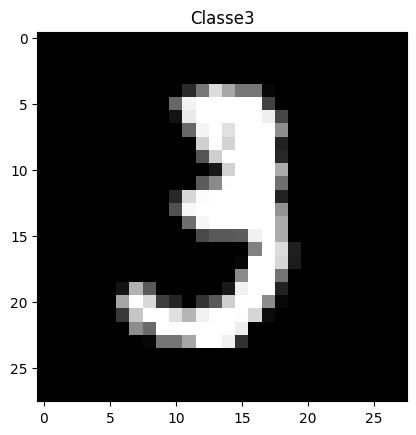

In [19]:
plt.imshow(X_treinamento[10], cmap='gray')
plt.title('Classe' + str(y_treinamento[10]))

In [20]:
X_treinamento.shape

(60000, 28, 28)

In [22]:
X_treinamento = X_treinamento.reshape(X_treinamento.shape[0], 28, 28, 1) #Se fosse uma imagem colorida seria o numero 3

In [26]:
X_teste = X_teste.reshape(X_teste.shape[0], 28, 28, 1)

In [28]:
X_treinamento.shape, X_teste.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [25]:
X_treinamento = X_treinamento.astype('float32')

In [29]:
X_teste = X_teste.astype('float32')

In [30]:
X_treinamento /= 255 #dividindo o valor da função treinamento
X_teste /= 255

In [31]:
X_treinamento.max(), X_treinamento.min()

(np.float32(1.0), np.float32(0.0))

In [33]:
y_treinamento #valores inteiros que representa os digitos

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [38]:
y_treinamento = np_utils.to_categorical(y_treinamento, 10)
y_teste = np_utils.to_categorical(y_teste, 10)

In [40]:
y_treinamento

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [45]:
y_treinamento[2]

array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])

In [65]:
rede_neural = Sequential()
rede_neural.add(InputLayer(shape = (28,28,1)))

rede_neural.add(Conv2D(filters = 32, kernel_size = (3,3), activation = 'relu'))
rede_neural.add(BatchNormalization())
rede_neural.add(MaxPooling2D(pool_size = (2, 2)))

rede_neural.add(Conv2D(filters = 32, kernel_size = (3,3), activation = 'relu'))
rede_neural.add(BatchNormalization())
rede_neural.add(MaxPooling2D(pool_size = (2, 2)))

rede_neural.add(Flatten())

rede_neural.add(Flatten())
rede_neural.add(Dense(units = 128, activation = 'relu'))
rede_neural.add(Dropout(0.2))
rede_neural.add(Dense(units = 128, activation = 'relu'))
rede_neural.add(Dropout(0.2))
rede_neural.add(Dense(units = 10, activation = 'softmax'))

In [55]:
13 * 13 * 32 #quantidade de neurônios na camada de entrada densa

5408

In [66]:
rede_neural.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 11, 11, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,154 (508.41 KB)

 Trainable params: 130,026 (507.91 KB)

 Non-trainable params: 128 (512.00 B)

In [67]:
rede_neural.compile(loss = 'categorical_crossentropy', optimizer= 'adam', metrics = ['accuracy'])


In [68]:
rede_neural.fit(X_treinamento, y_treinamento, batch_size = 128,
                  epochs = 5, validation_data = (X_teste, y_teste))

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 132ms/step - accuracy: 0.9389 - loss: 0.1995 - val_accuracy: 0.9641 - val_loss: 0.1232
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 134ms/step - accuracy: 0.9808 - loss: 0.0642 - val_accuracy: 0.9868 - val_loss: 0.0419
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 133ms/step - accuracy: 0.9859 - loss: 0.0485 - val_accuracy: 0.9888 - val_loss: 0.0347
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 135ms/step - accuracy: 0.9893 - loss: 0.0370 - val_accuracy: 0.9896 - val_loss: 0.0340
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 64s 136ms/step - accuracy: 0.9909 - loss: 0.0300 - val_accuracy: 0.9902 - val_loss: 0.0306


In [61]:
resultado = rede_neural.evaluate(X_teste, y_teste) #Registros sendo enviados para a rede neural

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9841 - loss: 0.0471


In [63]:
resultado #essa estrutura simples conseguiu resolver de forma eficiente

[0.04708138108253479, 0.9840999841690063]

### Melhora da Estrutura da Rede Neural Convencional



In [70]:
resultado = rede_neural.evaluate(X_teste, y_teste)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9902 - loss: 0.0306


In [71]:
resultado

[0.030624713748693466, 0.9901999831199646]